*💼 BUSINESS QUESTIONS YANG HARUS DIJAWAB*

1. Channel mana yang paling cost-efficient (ROI tertinggi dengan acquisition cost rendah)?
2. Campaign type apa yang paling cocok untuk masing-masing customer segment?
3. Apakah campaign yang lebih lama (60 days) lebih profitable dibanding yang pendek (15 days)?
4. Location mana yang memberikan ROI terbaik? Apakah perlu fokus geographic?

**Optimization Questions:**
5. Jika budget kita $10 juta untuk next quarter, bagaimana allocation strategy yang optimal?
6. Customer segment mana yang underperforming dan perlu strategy baru?
7. Apakah ada kombinasi channel + campaign type yang consistently sukses?

**Prediction Questions:**
8. Berapa probabilitas sukses jika kita run Email campaign via Google Ads ke Tech Enthusiasts segment dengan budget $50K?
9. Features apa yang paling critical untuk dioptimasi agar campaign sukses?
10. Berapa estimated savings jika kita gunakan model ini untuk screening campaign sebelum execution?

In [70]:
from google.colab import drive
%pip install ipython-sql sqlalchemy
%load_ext sql
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [71]:
engine = create_engine('sqlite://')

id_url = '11fwLaRQXY3-VJErF1ChM9VdvvY-6FCVk'
url_csv = f'https://drive.google.com/uc?export=download&id={id_url}'
df = pd.read_csv(url_csv)
df.to_sql('datacampaign', con=engine, if_exists='replace', index=False)

%sql sqlite://

query_table = """ SELECT * 
FROM datacampaign
LIMIT 5;
"""

result_table = pd.read_sql_query(query_table, engine)
print(result_table.head())

   Campaign_ID              Company Campaign_Type Target_Audience Duration  \
0            1  Innovate Industries         Email       Men 18-24  30 days   
1            2       NexGen Systems         Email     Women 35-44  60 days   
2            3    Alpha Innovations    Influencer       Men 25-34  30 days   
3            4   DataTech Solutions       Display        All Ages  60 days   
4            5       NexGen Systems         Email       Men 25-34  15 days   

  Channel_Used  Conversion_Rate  Acquisition_Cost   ROI     Location  \
0   Google Ads             0.04           16174.0  6.29      Chicago   
1   Google Ads             0.12           11566.0  5.61     New York   
2      YouTube             0.07           10200.0  7.18  Los Angeles   
3      YouTube             0.11           12724.0  5.55        Miami   
4      YouTube             0.05           16452.0  6.50  Los Angeles   

   Language  Clicks  Impressions  Engagement_Score     Customer_Segment  \
0   Spanish     506    

In [72]:
df.shape

(200000, 16)

In [73]:
df.dtypes

,0
Campaign_ID,int64
Company,object
Campaign_Type,object
Target_Audience,object
Duration,object
Channel_Used,object
Conversion_Rate,float64
Acquisition_Cost,float64
ROI,float64
Location,object


In [74]:
# ubah kolom duration dari object ke int tapi notes di headnya bahwa intnya = days

df['Duration_Days'] = df['Duration'].str.replace(' days', '').astype(int)
df.drop('Duration', axis=1, inplace=True)
df.dtypes

,0
Campaign_ID,int64
Company,object
Campaign_Type,object
Target_Audience,object
Channel_Used,object
Conversion_Rate,float64
Acquisition_Cost,float64
ROI,float64
Location,object
Language,object


In [75]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

,0
Campaign_ID,int64
Company,object
Campaign_Type,object
Target_Audience,object
Channel_Used,object
Conversion_Rate,float64
Acquisition_Cost,float64
ROI,float64
Location,object
Language,object


In [76]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  object        
 2   Campaign_Type     200000 non-null  object        
 3   Target_Audience   200000 non-null  object        
 4   Channel_Used      200000 non-null  object        
 5   Conversion_Rate   200000 non-null  float64       
 6   Acquisition_Cost  200000 non-null  float64       
 7   ROI               200000 non-null  float64       
 8   Location          200000 non-null  object        
 9   Language          200000 non-null  object        
 10  Clicks            200000 non-null  int64         
 11  Impressions       200000 non-null  int64         
 12  Engagement_Score  200000 non-null  int64         
 13  Customer_Segment  200000 non-null  object        
 14  Date

In [77]:
df.isna().sum()

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0
Language,0


In [78]:
df.describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score,Date,Duration_Days
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000,200000.000000
mean,100000.500000,0.080070,12504.393040,5.002438,549.772030,5507.301520,5.494710,2021-07-01 23:35:09.600000,37.503975
min,1.000000,0.010000,5000.000000,2.000000,100.000000,1000.000000,1.000000,2021-01-01 00:00:00,15.000000
25%,50000.750000,0.050000,8739.750000,3.500000,325.000000,3266.000000,3.000000,2021-04-02 00:00:00,30.000000
50%,100000.500000,0.080000,12496.500000,5.010000,550.000000,5517.500000,5.000000,2021-07-02 00:00:00,30.000000
75%,150000.250000,0.120000,16264.000000,6.510000,775.000000,7753.000000,8.000000,2021-10-01 00:00:00,45.000000
max,200000.000000,0.150000,20000.000000,8.000000,1000.000000,10000.000000,10.000000,2021-12-31 00:00:00,60.000000
std,57735.171256,0.040602,4337.664545,1.734488,260.019056,2596.864286,2.872581,NaN,16.746720


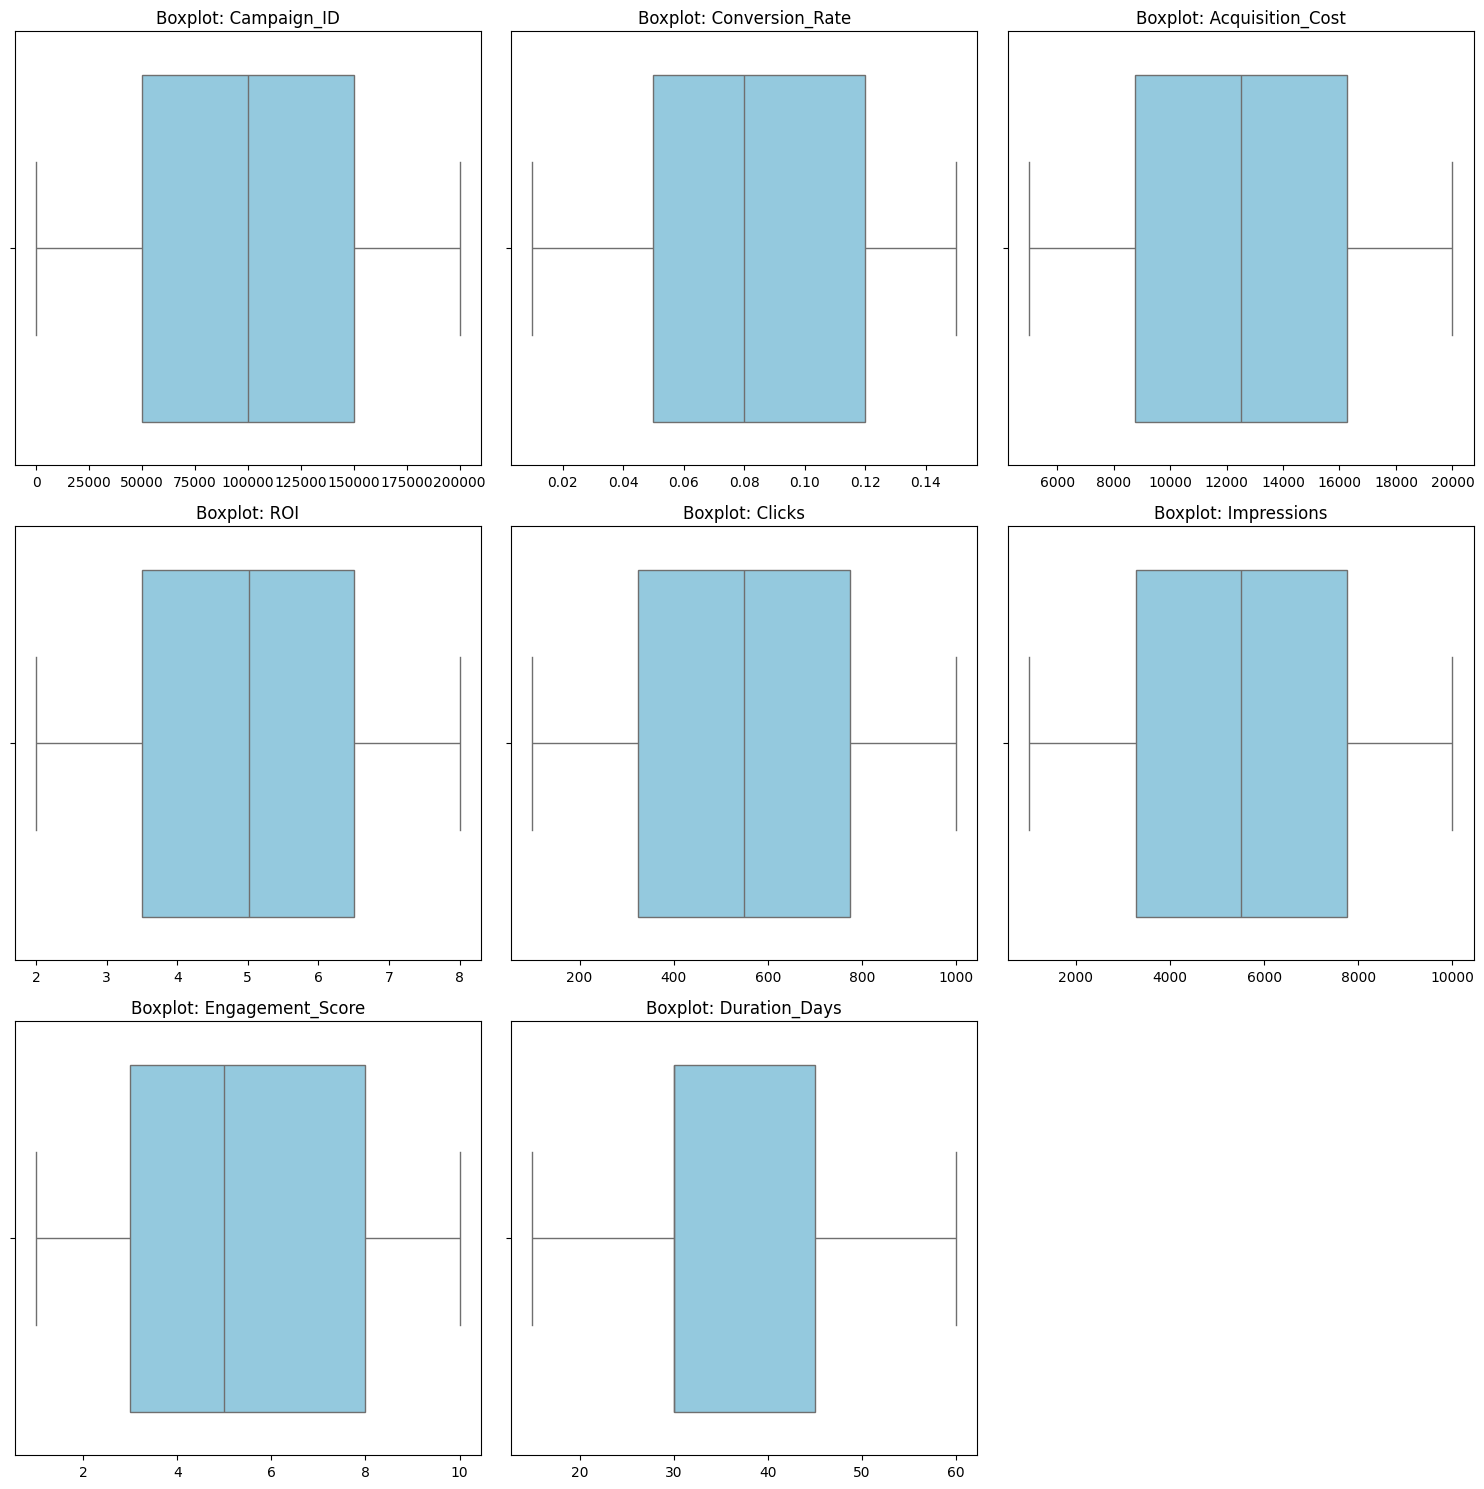

In [79]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numerical_cols)
n_rows = math.ceil(n_cols / 3)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, 3, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [80]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False)) 
    print("\n")

for col in categorical_cols:
    num_unique = df[col].nunique()
    print(f"{col}: {num_unique} unique values")


--- Company ---
Company
TechCorp               40237
Alpha Innovations      40051
DataTech Solutions     40012
NexGen Systems         39991
Innovate Industries    39709
Name: count, dtype: int64


--- Campaign_Type ---
Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64


--- Target_Audience ---
Target_Audience
Men 18-24      40258
Men 25-34      40023
All Ages       40019
Women 25-34    40013
Women 35-44    39687
Name: count, dtype: int64


--- Channel_Used ---
Channel_Used
Email         33599
Google Ads    33438
YouTube       33392
Instagram     33392
Website       33360
Facebook      32819
Name: count, dtype: int64


--- Location ---
Location
Miami          40269
New York       40024
Chicago        40010
Los Angeles    39947
Houston        39750
Name: count, dtype: int64


--- Language ---
Language
Mandarin    40255
Spanish     40102
German      39983
English     39896
French      39764

  Channel_Used   Avg_ROI      Avg_Cost
0     Facebook  5.018699  12510.900942
1      Website  5.014167  12487.814748
2   Google Ads  5.003141  12528.031401
3        Email  4.996487  12526.387809
4      YouTube  4.993754  12481.390213
5    Instagram  4.988706  12491.760002


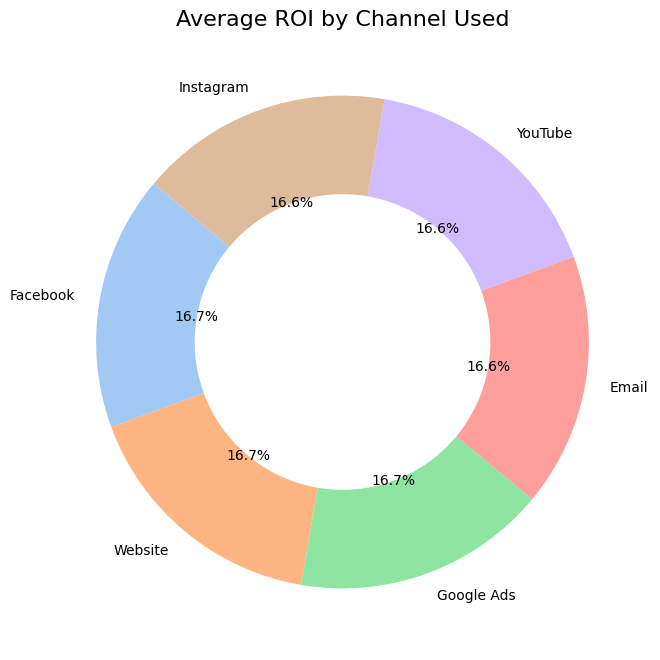

In [81]:
# channel paling bagus = ROI tinggi dan cost rendah

query_channel_performance = """
SELECT
    Channel_Used,
    AVG(ROI) AS Avg_ROI,
    AVG(Acquisition_Cost) AS Avg_Cost
FROM
    datacampaign
GROUP BY
    Channel_Used
ORDER BY
    Avg_ROI DESC;
"""

channel_performance = pd.read_sql_query(query_channel_performance, engine)
print(channel_performance)

# visualisasi channel performance dengan donut chart
plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel')[0:len(channel_performance)]
plt.pie(channel_performance['Avg_ROI'], labels=channel_performance['Channel_Used'], colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'width':0.4})
plt.title('Average ROI by Channel Used', fontsize=16)
plt.show()

  Target_Audience Gender Age_Group
0       Men 18-24    Men     18-24
1     Women 35-44  Women     35-44
2       Men 25-34    Men     25-34
3        All Ages    All  All Ages
4       Men 25-34    Men     25-34
['18-24' '35-44' '25-34' 'All Ages']
  Gender Age_Group Campaign_Type   ROI  Acquisition_Cost  Holistic_Score
0    All  All Ages        Search  7.72            7431.0           87.13
1    Men     18-24    Influencer  7.67            5723.0           94.05
2    Men     25-34       Display  7.91            5764.0           89.41
3  Women     25-34    Influencer  7.81            7663.0           87.08
4  Women     35-44       Display  7.90            7149.0           91.23


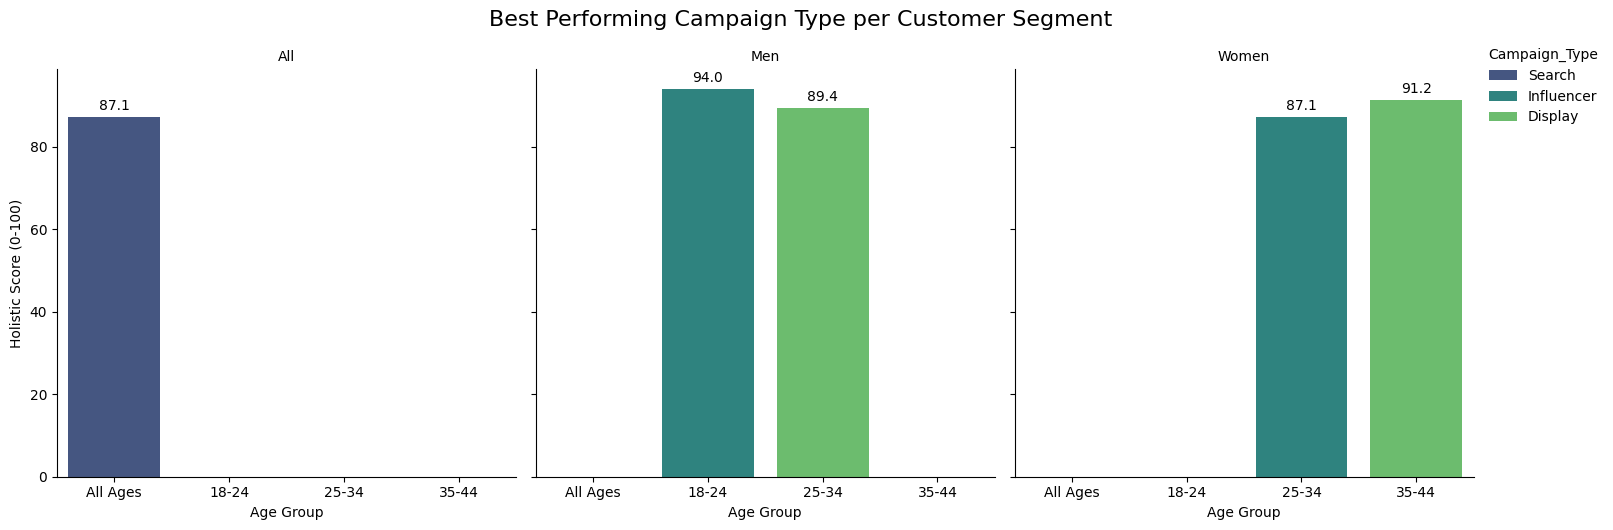

In [94]:
# campaign type yg paling cocok masing2 customer segment

split_data = df['Target_Audience'].str.split(' ', n=1, expand=True)
df['Gender'] = split_data[0]
df['Age_Group'] = split_data[1]
mask_all_ages = (df['Target_Audience'] == 'All Ages')
df.loc[mask_all_ages, 'Gender'] = 'All'
df.loc[mask_all_ages, 'Age_Group'] = 'All Ages'
print(df[['Target_Audience', 'Gender', 'Age_Group']].head())
print(df['Age_Group'].unique())

df.to_sql('datacampaign', con=engine, if_exists='replace', index=False)

query_campaign_type = """
WITH 
-- 1. BERSIHKAN DATA & HITUNG CTR
Base_Data AS (
    SELECT 
        *,
        -- Logika Gender & Age Split (seperti sebelumnya)
        CASE WHEN Target_Audience = 'All Ages' THEN 'All' 
             ELSE SUBSTR(Target_Audience, 1, INSTR(Target_Audience, ' ') - 1) 
        END AS Gender_Clean,
        CASE WHEN Target_Audience = 'All Ages' THEN 'All Ages' 
             ELSE SUBSTR(Target_Audience, INSTR(Target_Audience, ' ') + 1) 
        END AS Age_Group_Clean,
        -- Hitung CTR (Cegah error dibagi 0)
        CAST(Clicks AS FLOAT) / NULLIF(Impressions, 0) AS CTR_Val
    FROM datacampaign
),

-- 2. CARI NILAI MIN & MAX UNTUK SETIAP METRIK (Untuk Normalisasi)
Stats AS (
    SELECT 
        MIN(ROI) as min_roi, MAX(ROI) as max_roi,
        MIN(Conversion_Rate) as min_conv, MAX(Conversion_Rate) as max_conv,
        MIN(Engagement_Score) as min_eng, MAX(Engagement_Score) as max_eng,
        MIN(Acquisition_Cost) as min_cost, MAX(Acquisition_Cost) as max_cost,
        MIN(CTR_Val) as min_ctr, MAX(CTR_Val) as max_ctr
    FROM Base_Data
),

-- 3. HITUNG SKOR (NORMALISASI + PEMBOBOTAN)
Scored_Data AS (
    SELECT 
        d.Campaign_Type,
        d.Gender_Clean AS Gender,
        d.Age_Group_Clean AS Age_Group,
        d.ROI,
        d.Acquisition_Cost,
        d.Conversion_Rate,
        
        -- Rumus Skor Gabungan (0-100)
        (
            -- ROI (Bobot 40%) - Makin tinggi makin bagus
            (0.40 * (d.ROI - s.min_roi) / (s.max_roi - s.min_roi)) +
            
            -- Conversion Rate (Bobot 20%) - Makin tinggi makin bagus
            (0.20 * (d.Conversion_Rate - s.min_conv) / (s.max_conv - s.min_conv)) +
            
            -- Engagement (Bobot 15%) - Makin tinggi makin bagus
            (0.15 * (d.Engagement_Score - s.min_eng) / (s.max_eng - s.min_eng)) +
            
            -- CTR (Bobot 15%) - Makin tinggi makin bagus
            (0.15 * (d.CTR_Val - s.min_ctr) / (s.max_ctr - s.min_ctr)) +
            
            -- Acquisition Cost (Bobot 10%) - MAKIN RENDAH MAKIN BAGUS (Rumus Dibalik)
            (0.10 * (s.max_cost - d.Acquisition_Cost) / (s.max_cost - s.min_cost))
        ) * 100 AS Final_Score

    FROM Base_Data d, Stats s -- Cross Join (menggabungkan data dengan nilai min/max)
)

-- 4. TAMPILKAN JUARA 1 PER SEGMEN (Ranking)
SELECT 
    Gender, 
    Age_Group, 
    Campaign_Type, 
    ROI,
    Acquisition_Cost,
    ROUND(Final_Score, 2) as Holistic_Score
FROM (
    SELECT 
        *,
        ROW_NUMBER() OVER(PARTITION BY Gender, Age_Group ORDER BY Final_Score DESC) as Rank
    FROM Scored_Data
)
WHERE Rank = 1
ORDER BY Gender, Age_Group;
"""

campaign_type_performance = pd.read_sql_query(query_campaign_type, engine)
print(campaign_type_performance)


g = sns.catplot(
    data=campaign_type_performance,
    kind="bar",
    x="Age_Group",
    y="Holistic_Score",
    hue="Campaign_Type",  # Warna batang akan menunjukkan jenis campaign pemenang
    col="Gender",         # Memisahkan grafik berdasarkan Gender (Male/Female/All)
    height=5,
    aspect=1,
    dodge=False,          # Batang tidak perlu digeser karena hanya ada 1 pemenang per kategori
    palette="viridis"     # Pilihan warna
)

g.fig.suptitle('Best Performing Campaign Type per Customer Segment', y=1.05, fontsize=16)
g.set_axis_labels("Age Group", "Holistic Score (0-100)")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3)

sns.move_legend(g, "upper right", bbox_to_anchor=(1, 1))

plt.show()


In [98]:
print(df['Duration_Days'].unique())

query_duration_analysis = """
SELECT 
    -- 1. Buat Kategori Durasi
    CASE 
        WHEN Duration_Days <= 30 THEN 'Short (<= 30 Days)'
        WHEN Duration_Days >= 50 THEN 'Long (>= 50 Days)'
        ELSE 'Medium (31-49 Days)' 
    END AS Duration_Category,

    -- 2. Hitung Rata-rata Metrik Kunci
    COUNT(Campaign_ID) as Total_Campaigns,
    AVG(ROI) as Avg_ROI,
    AVG(Conversion_Rate) as Avg_Conversion_Rate,
    AVG(Acquisition_Cost) as Avg_Acquisition_Cost,
    AVG(Engagement_Score) as Avg_Engagement_Score

FROM datacampaign
GROUP BY 1
ORDER BY Avg_ROI DESC; -- Urutkan dari yang paling profitable
"""

df_duration = pd.read_sql_query(query_duration_analysis, engine)
print(df_duration)

[30 60 15 45]
     Duration_Category  Total_Campaigns   Avg_ROI  Avg_Conversion_Rate  \
0    Long (>= 50 Days)            49866  5.006480             0.080048   
1   Short (<= 30 Days)           100034  5.002832             0.080139   
2  Medium (31-49 Days)            50100  4.997627             0.079952   

   Avg_Acquisition_Cost  Avg_Engagement_Score  
0          12514.778907              5.481510  
1          12498.861297              5.503669  
2          12505.100838              5.489960  


/tmp/ipython-input-678878305.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='Duration_Category', y='ROI', order=['Short', 'Medium', 'Long'], palette='Set2', ax=axes[0])


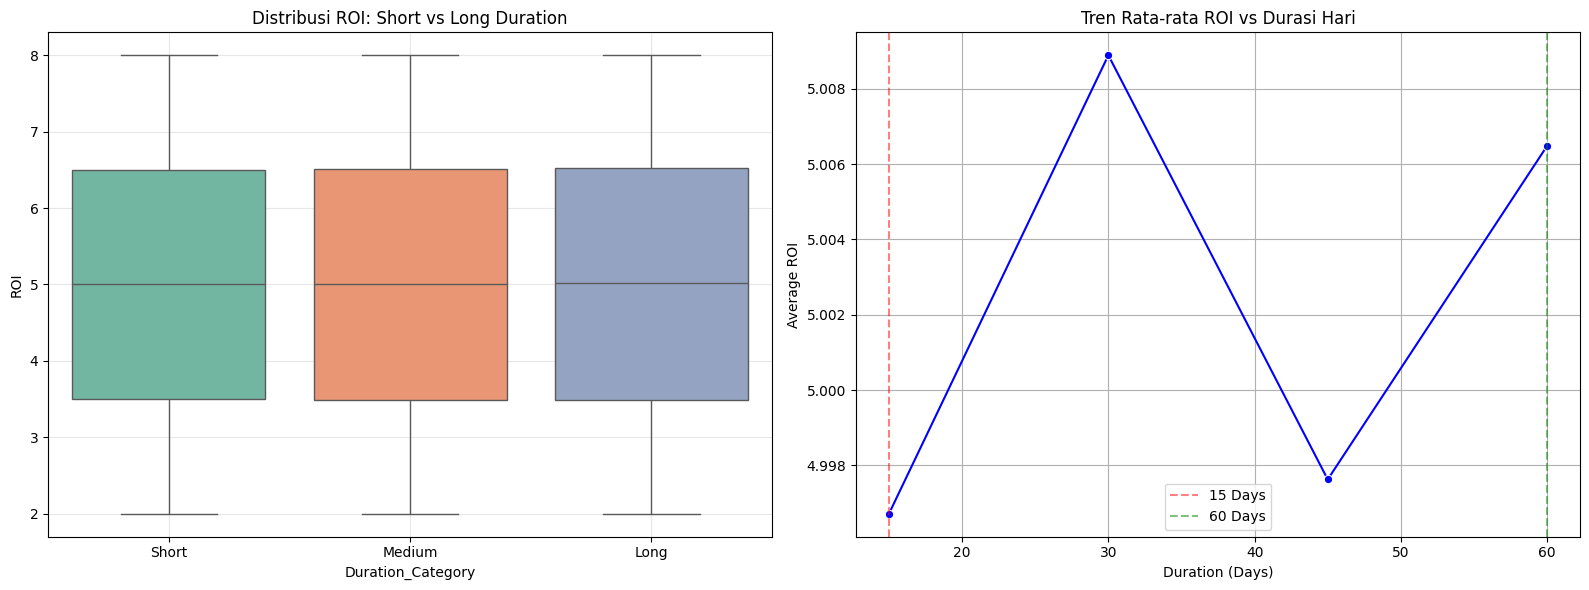

In [99]:
# Ambil data mentah yang diperlukan (jangan di-aggregate dulu untuk Boxplot)
query_raw_duration = "SELECT Duration_Days, ROI, Acquisition_Cost FROM datacampaign"
df_raw = pd.read_sql_query(query_raw_duration, engine)

# Buat Kategori di Pandas untuk visualisasi
def categorize_duration(days):
    if days <= 30: return 'Short'
    elif days >= 50: return 'Long'
    else: return 'Medium'

df_raw['Duration_Category'] = df_raw['Duration_Days'].apply(categorize_duration)

# --- VISUALISASI ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. BOXPLOT: Membandingkan Distribusi ROI (Stabilitas vs Profitabilitas)
sns.boxplot(data=df_raw, x='Duration_Category', y='ROI', order=['Short', 'Medium', 'Long'], palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi ROI: Short vs Long Duration')
axes[0].set_ylabel('ROI')
axes[0].grid(True, alpha=0.3)

# 2. LINE CHART: Melihat Tren ROI berdasarkan Angka Pasti Durasi
# Kita group by Duration_Days agar dapat garis tren
df_trend = df_raw.groupby('Duration_Days')[['ROI', 'Acquisition_Cost']].mean().reset_index()

sns.lineplot(data=df_trend, x='Duration_Days', y='ROI', marker='o', color='b', ax=axes[1])
axes[1].set_title('Tren Rata-rata ROI vs Durasi Hari')
axes[1].set_ylabel('Average ROI')
axes[1].set_xlabel('Duration (Days)')
axes[1].grid(True)

# Tambahkan garis vertikal pembatas 15 dan 60 hari
axes[1].axvline(15, color='r', linestyle='--', alpha=0.5, label='15 Days')
axes[1].axvline(60, color='g', linestyle='--', alpha=0.5, label='60 Days')
axes[1].legend()

plt.tight_layout()
plt.show()

      Location   Avg_ROI
0        Miami  5.012282
1  Los Angeles  5.010876
2      Houston  5.007203
3      Chicago  5.001590
4     New York  4.980228


/tmp/ipython-input-4003242114.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=location_performance, x='Location', y='Avg_ROI', palette='Blues_d')


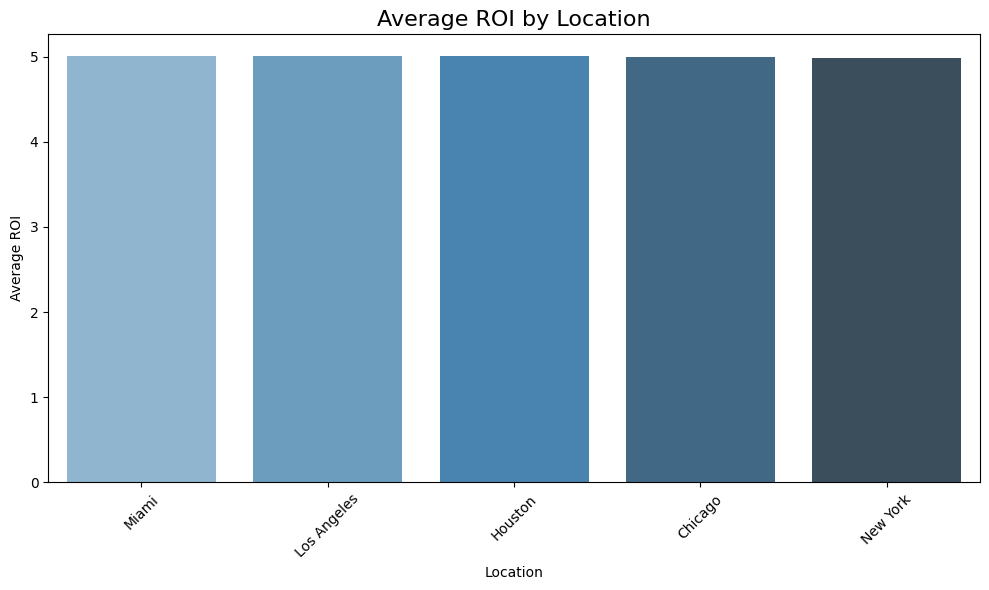

In [101]:

query_location_performance = """
SELECT
    Location,
    AVG(ROI) AS Avg_ROI
FROM
    datacampaign
GROUP BY
    Location
ORDER BY
    Avg_ROI DESC;
"""

location_performance = pd.read_sql_query(query_location_performance, engine)
print(location_performance)

plt.figure(figsize=(10, 6))
sns.barplot(data=location_performance, x='Location', y='Avg_ROI', palette='Blues_d')
plt.title('Average ROI by Location', fontsize=16)
plt.xlabel('Location')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()